In [9]:
# --- Cell 1: imports and setup ---
import os
import numpy as np
import pandas as pd
from fredapi import Fred
from dotenv import load_dotenv
import matplotlib.pyplot as plt

load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

In [10]:
# --- Cell 2: helper functions ---

def get_series(ticker, name, filepath):
    if os.path.exists(filepath):
        data = pd.read_csv(filepath, index_col=0, parse_dates=True).squeeze()
        data.name = name
    else:
        data = fred.get_series(ticker)
        data.index = pd.to_datetime(data.index)
        data.name = name
        data.to_csv(filepath, header=True)

    n_missing = data.isna().sum()
    print(f"{name}: {n_missing} missing values")
    if n_missing > 0:
        print(data[data.isna()])

    data = data.ffill().dropna()
    return data


def resample_to_monthly(series, method='mean'):
    if method == 'mean':
        return series.resample('ME').mean()
    elif method == 'last':
        return series.resample('ME').last()
    elif method == 'max':
        return series.resample('ME').max()
    elif method == 'min':
        return series.resample('ME').min()
    else:
        raise ValueError("method must be 'mean', 'last', 'max', or 'min'")

In [11]:
# --- Cell 3: pull + resample all 17 series ---

series_config = {
    'CCSA':      {'name': 'continued_claims', 'method': 'mean'},
    'ICSA':      {'name': 'initial_claims',   'method': 'mean'},
    'BAA10Y':    {'name': 'baa10y_spread',    'method': 'last'},
    'NFCI':      {'name': 'nfci',             'method': 'last'},
    'T10Y2Y':    {'name': 't10y2y',           'method': 'last'},
    'CPIAUCSL':  {'name': 'cpi',              'method': 'mean'},
    'INDPRO':    {'name': 'indpro',           'method': 'mean'},
    'TB3MS':     {'name': 'tb3ms',            'method': 'mean'},
    'DCOILWTICO':{'name': 'wti',              'method': 'mean'},
    'TCU':       {'name': 'tcu',              'method': 'mean'},
    'UNRATE':    {'name': 'unrate',           'method': 'mean'},
    'UMCSENT':   {'name': 'umcsent',          'method': 'mean'},
    'BUSLOANS':  {'name': 'busloans',         'method': 'mean'},
    'CUMFNS':    {'name': 'cumfns',           'method': 'mean'},
    'M2SL':      {'name': 'm2',               'method': 'mean'},
    'PAYEMS':    {'name': 'payems',           'method': 'mean'},
    'PPIACO':    {'name': 'ppiaco',           'method': 'mean'},
}

monthly_series = {}

for ticker, cfg in series_config.items():
    name = cfg['name']
    filepath = f"../data/{name}.csv"
    raw = get_series(ticker, name, filepath)
    monthly = resample_to_monthly(raw, method=cfg['method'])
    monthly.name = f"{name}_monthly"
    monthly_series[ticker] = monthly

continued_claims: 0 missing values
initial_claims: 0 missing values
baa10y_spread: 440 missing values
1986-01-20   NaN
1986-02-17   NaN
1986-03-28   NaN
1986-05-26   NaN
1986-07-04   NaN
              ..
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-04-03   NaN
2026-05-25   NaN
Name: baa10y_spread, Length: 440, dtype: float64
nfci: 0 missing values
t10y2y: 549 missing values
1976-07-05   NaN
1976-09-06   NaN
1976-10-11   NaN
1976-11-02   NaN
1976-11-11   NaN
              ..
2025-12-25   NaN
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-05-25   NaN
Name: t10y2y, Length: 549, dtype: float64
cpi: 1 missing values
2025-10-01   NaN
Name: cpi, dtype: float64
indpro: 0 missing values
tb3ms: 0 missing values
wti: 371 missing values
1986-02-17   NaN
1986-03-28   NaN
1986-05-26   NaN
1986-07-04   NaN
1986-09-01   NaN
              ..
2026-01-01   NaN
2026-01-19   NaN
2026-02-16   NaN
2026-04-03   NaN
2026-05-25   NaN
Name: wti, Length: 371, dtype: float64
tcu: 0 missing valu

In [12]:
# --- Cell 4: apply confirmed transforms (level / diff / log_diff) ---

transform_config = {
    'CCSA':       {'kind': 'level',    'ensae_name': 'Continued_claims'},
    'ICSA':       {'kind': 'level',    'ensae_name': 'Initial_claims'},
    'BAA10Y':     {'kind': 'level',    'ensae_name': 'Credit_spread'},
    'NFCI':       {'kind': 'level',    'ensae_name': 'NFCI'},
    'T10Y2Y':     {'kind': 'level',    'ensae_name': 'Slope'},
    'CUMFNS':     {'kind': 'level',    'ensae_name': 'CUMFNS'},
    'CPIAUCSL':   {'kind': 'log_diff', 'ensae_name': 'Log_CPI_diff'},
    'INDPRO':     {'kind': 'log_diff', 'ensae_name': 'Log_INDPRO_diff'},
    'TB3MS':      {'kind': 'diff',     'ensae_name': 'TB3MS_diff'},
    'DCOILWTICO': {'kind': 'log_diff', 'ensae_name': 'WTI_Returns'},
    'TCU':        {'kind': 'diff',     'ensae_name': 'TCU_diff'},
    'UNRATE':     {'kind': 'diff',     'ensae_name': 'UNRATE_diff'},
    'UMCSENT':    {'kind': 'diff',     'ensae_name': 'UMCSENT_diff'},
    'BUSLOANS':   {'kind': 'log_diff', 'ensae_name': 'Log_BUSLOANS_diff'},
    'M2SL':       {'kind': 'log_diff', 'ensae_name': 'Log_M2SL_diff'},
    'PAYEMS':     {'kind': 'log_diff', 'ensae_name': 'Log_PAYEMS_diff'},
    'PPIACO':     {'kind': 'log_diff', 'ensae_name': 'Log_PPIACO_diff'},
}


def apply_transform(series, kind):
    if kind == 'log_diff':
        return np.log(series).diff()
    elif kind == 'diff':
        return series.diff()
    elif kind == 'level':
        return series.copy()
    else:
        raise ValueError("kind must be 'log_diff', 'diff', or 'level'")


transformed_series = {}
for ticker, cfg in transform_config.items():
    monthly = monthly_series[ticker]
    transformed = apply_transform(monthly, cfg['kind'])
    transformed.name = cfg['ensae_name']
    transformed_series[ticker] = transformed

stationary_df = pd.concat(transformed_series.values(), axis=1, sort=False)
stationary_df = stationary_df.dropna()

print("Full sample:", stationary_df.shape, stationary_df.index.min(), "to", stationary_df.index.max())

Full sample: (483, 17) 1986-02-28 00:00:00 to 2026-04-30 00:00:00


In [13]:
# --- Cell 5: exclude COVID months (2020-02 to 2020-12) ---

covid_start, covid_end = '2020-02-01', '2020-12-31'
covid_mask = ~((stationary_df.index >= covid_start) & (stationary_df.index <= covid_end))

stationary_df_excl_covid = stationary_df.loc[covid_mask].copy()

print(f"Excl. COVID sample: {stationary_df_excl_covid.shape[0]} months "
      f"({stationary_df.shape[0] - stationary_df_excl_covid.shape[0]} months removed)")
print(stationary_df_excl_covid.shape)
stationary_df_excl_covid.head()

Excl. COVID sample: 472 months (11 months removed)
(472, 17)


,Continued_claims,Initial_claims,Credit_spread,NFCI,Slope,CUMFNS,Log_CPI_diff,Log_INDPRO_diff,TB3MS_diff,WTI_Returns,TCU_diff,UNRATE_diff,UMCSENT_diff,Log_BUSLOANS_diff,Log_M2SL_diff,Log_PAYEMS_diff,Log_PPIACO_diff
1986-02-28,2568500.0,369500.0,2.49,-0.305,0.42,78.2670,-0.001821,-0.007044,-0.01,-0.392473,-0.6629,0.5,0.3,0.001902,0.004307,0.001164,-0.014642
1986-03-31,2593600.0,381200.0,2.92,-0.341,0.47,77.9205,-0.005484,-0.007148,-0.50,-0.209865,-0.6548,0.0,-0.8,0.007531,0.008006,0.000880,-0.013862
1986-04-30,2608750.0,385750.0,2.78,-0.427,0.55,78.2571,-0.003673,0.001433,-0.50,0.022938,0.0278,-0.1,1.1,0.004182,0.009704,0.001888,-0.007004
1986-05-31,2671000.0,386000.0,2.36,-0.481,0.69,78.2798,0.002756,0.001476,0.09,0.184702,0.0366,0.1,-1.4,0.001208,0.010501,0.001280,0.004008
1986-06-30,2635000.0,370500.0,2.81,-0.450,0.54,77.8771,0.003663,-0.004037,0.06,-0.140378,-0.3918,0.0,4.5,0.006538,0.007785,-0.000937,-0.001001


In [14]:
# --- Cell 6: correlation matrix, COVID-excluded ---

corr_matrix = stationary_df_excl_covid.corr()
corr_matrix.round(3)

,Continued_claims,Initial_claims,Credit_spread,NFCI,Slope,CUMFNS,Log_CPI_diff,Log_INDPRO_diff,TB3MS_diff,WTI_Returns,TCU_diff,UNRATE_diff,UMCSENT_diff,Log_BUSLOANS_diff,Log_M2SL_diff,Log_PAYEMS_diff,Log_PPIACO_diff
Continued_claims,1.000,0.897,0.556,0.217,0.739,-0.644,-0.135,-0.049,-0.184,0.037,0.026,0.173,0.050,-0.454,0.151,-0.459,0.024
Initial_claims,0.897,1.000,0.467,0.271,0.598,-0.388,-0.095,-0.103,-0.257,0.008,-0.070,0.192,0.029,-0.380,0.249,-0.397,0.015
Credit_spread,0.556,0.467,1.000,0.535,0.520,-0.680,-0.323,-0.326,-0.248,-0.142,-0.234,0.269,-0.028,-0.184,0.324,-0.533,-0.232
NFCI,0.217,0.271,0.535,1.000,-0.033,-0.203,-0.107,-0.314,-0.167,-0.124,-0.279,0.349,-0.068,-0.054,0.139,-0.469,-0.185
Slope,0.739,0.598,0.520,-0.033,1.000,-0.548,-0.134,0.006,-0.195,0.002,0.120,-0.001,0.018,-0.320,0.134,-0.261,0.029
CUMFNS,-0.644,-0.388,-0.680,-0.203,-0.548,1.000,0.190,0.243,0.150,0.006,0.090,-0.200,-0.034,0.430,-0.125,0.566,0.046
Log_CPI_diff,-0.135,-0.095,-0.323,-0.107,-0.134,0.190,1.000,0.083,0.140,0.505,0.096,-0.113,-0.179,0.048,-0.116,0.243,0.727
Log_INDPRO_diff,-0.049,-0.103,-0.326,-0.314,0.006,0.243,0.083,1.000,0.176,0.099,0.965,-0.263,-0.064,0.042,-0.126,0.407,0.136
TB3MS_diff,-0.184,-0.257,-0.248,-0.167,-0.195,0.150,0.140,0.176,1.000,0.091,0.189,-0.167,0.156,0.118,-0.311,0.325,0.092
WTI_Returns,0.037,0.008,-0.142,-0.124,0.002,0.006,0.505,0.099,0.091,1.000,0.119,-0.081,-0.084,-0.018,-0.097,0.068,0.626


In [15]:
# --- Cell 7: PCA — eigendecomposition on the COVID-excluded correlation matrix ---

eigvals, eigvecs = np.linalg.eigh(corr_matrix.values)

# eigh returns ascending order -> flip to descending (PC1 = most variance first)
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]

n_vars = corr_matrix.shape[0]
pc_names = [f'PC{i+1}' for i in range(n_vars)]

explained_var = eigvals / eigvals.sum()
cumulative_var = explained_var.cumsum()

variance_df = pd.DataFrame({
    'eigenvalue': eigvals,
    'explained_variance_%': explained_var * 100,
    'cumulative_%': cumulative_var * 100
}, index=pc_names)

print(variance_df.round(2))

      eigenvalue  explained_variance_%  cumulative_%
PC1         4.77                 28.06         28.06
PC2         2.62                 15.40         43.46
PC3         1.95                 11.50         54.96
PC4         1.38                  8.15         63.10
PC5         1.11                  6.55         69.65
PC6         0.91                  5.33         74.99
PC7         0.82                  4.83         79.82
PC8         0.69                  4.04         83.86
PC9         0.64                  3.78         87.64
PC10        0.59                  3.45         91.09
PC11        0.47                  2.79         93.88
PC12        0.38                  2.21         96.08
PC13        0.24                  1.43         97.51
PC14        0.22                  1.32         98.83
PC15        0.15                  0.87         99.69
PC16        0.04                  0.22         99.91
PC17        0.01                  0.09        100.00


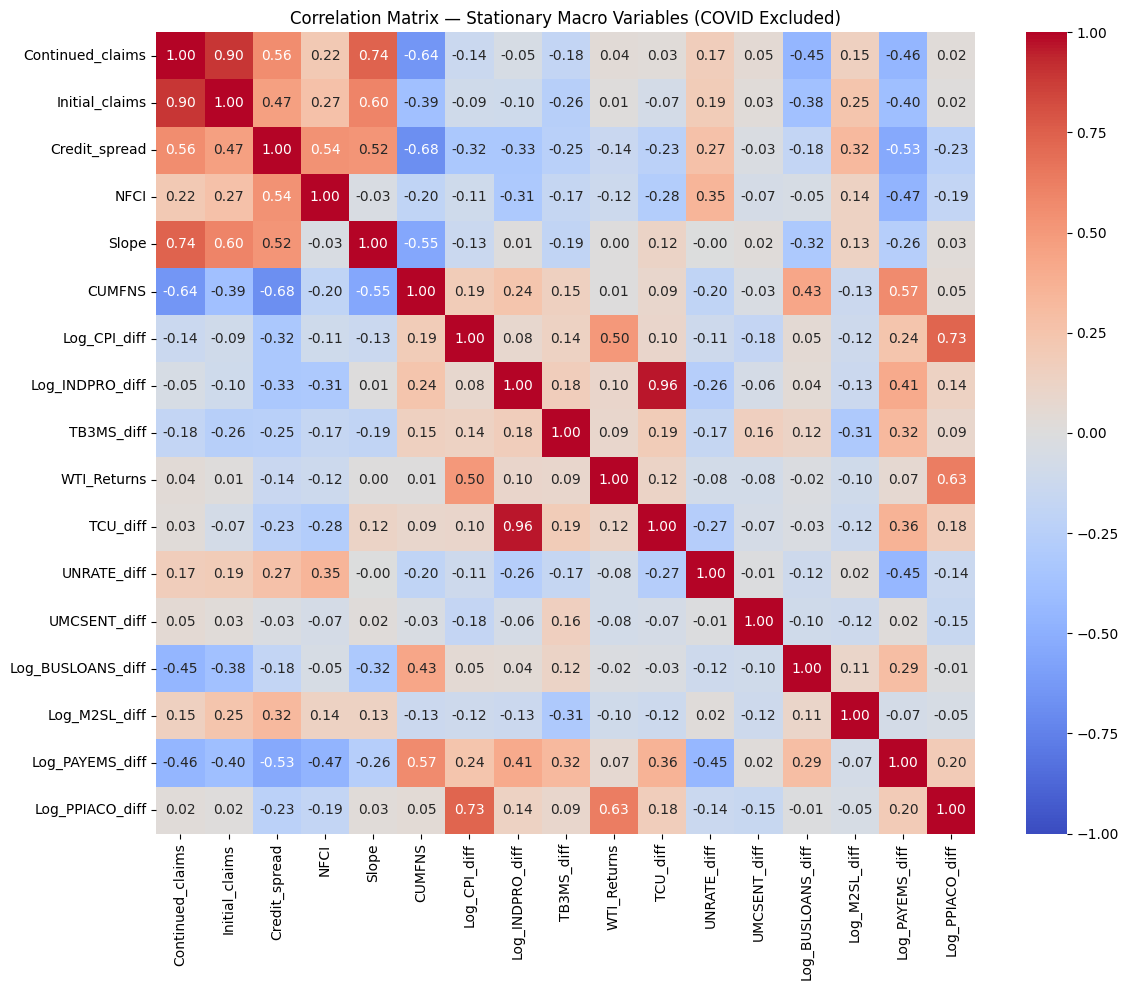

In [16]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Stationary Macro Variables (COVID Excluded)')
plt.tight_layout()
plt.show()

In [17]:
# --- Cell 7: PCA — eigendecomposition on the COVID-excluded correlation matrix ---

eigvals, eigvecs = np.linalg.eigh(corr_matrix.values)

# eigh returns ascending order -> flip to descending (PC1 = most variance first)
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]

n_vars = corr_matrix.shape[0]
pc_names = [f'PC{i+1}' for i in range(n_vars)]

explained_var = eigvals / eigvals.sum()
cumulative_var = explained_var.cumsum()

variance_df = pd.DataFrame({
    'eigenvalue': eigvals,
    'explained_variance_%': explained_var * 100,
    'cumulative_%': cumulative_var * 100
}, index=pc_names)

print(variance_df.round(2))

      eigenvalue  explained_variance_%  cumulative_%
PC1         4.77                 28.06         28.06
PC2         2.62                 15.40         43.46
PC3         1.95                 11.50         54.96
PC4         1.38                  8.15         63.10
PC5         1.11                  6.55         69.65
PC6         0.91                  5.33         74.99
PC7         0.82                  4.83         79.82
PC8         0.69                  4.04         83.86
PC9         0.64                  3.78         87.64
PC10        0.59                  3.45         91.09
PC11        0.47                  2.79         93.88
PC12        0.38                  2.21         96.08
PC13        0.24                  1.43         97.51
PC14        0.22                  1.32         98.83
PC15        0.15                  0.87         99.69
PC16        0.04                  0.22         99.91
PC17        0.01                  0.09        100.00


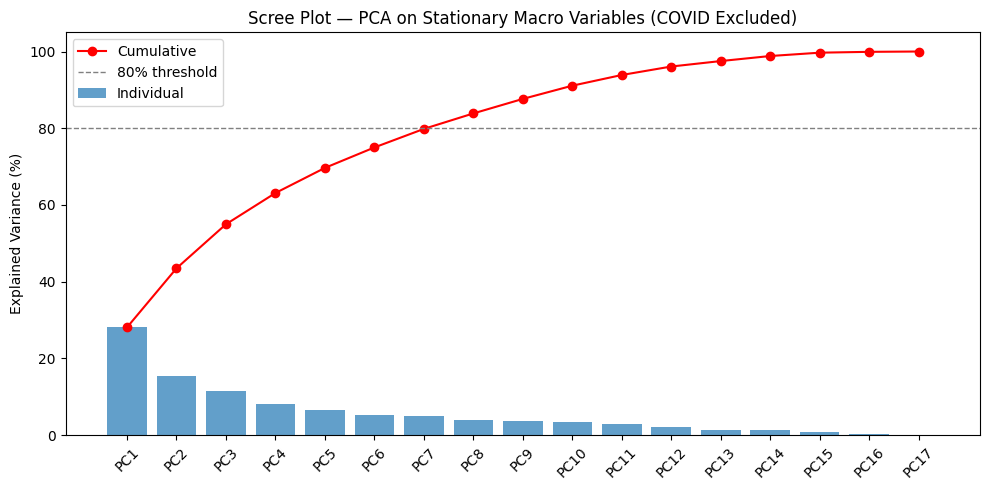

In [18]:
# --- Cell 8: scree plot ---

plt.figure(figsize=(10, 5))
plt.bar(pc_names, explained_var * 100, alpha=0.7, label='Individual')
plt.plot(pc_names, cumulative_var * 100, color='red', marker='o', label='Cumulative')
plt.axhline(80, color='grey', linestyle='--', linewidth=1, label='80% threshold')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot — PCA on Stationary Macro Variables (COVID Excluded)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# --- Cell 9: loadings matrix ---

loadings = pd.DataFrame(
    eigvecs,
    index=corr_matrix.columns,
    columns=pc_names
)

print("Loadings for PC1–PC8:")
print(loadings.iloc[:, :8].round(3))

Loadings for PC1–PC8:
                     PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
Continued_claims  -0.355  0.320 -0.076  0.047 -0.053 -0.049 -0.136  0.229
Initial_claims    -0.327  0.252 -0.019 -0.056 -0.089  0.016 -0.393  0.427
Credit_spread     -0.377 -0.009 -0.017 -0.123  0.029 -0.366  0.190 -0.154
NFCI              -0.235 -0.178  0.168 -0.093  0.413 -0.371 -0.208  0.165
Slope             -0.275  0.327 -0.161 -0.032 -0.232 -0.020  0.155  0.070
CUMFNS             0.340 -0.157  0.013 -0.138  0.007  0.114 -0.419  0.360
Log_CPI_diff       0.176  0.272  0.467 -0.002  0.023 -0.033 -0.078  0.136
Log_INDPRO_diff    0.208  0.334 -0.379 -0.165  0.349 -0.021 -0.146 -0.139
TB3MS_diff         0.188  0.053 -0.070  0.404  0.049 -0.639  0.135  0.272
WTI_Returns        0.092  0.327  0.405  0.065  0.005 -0.092 -0.024 -0.354
TCU_diff           0.170  0.382 -0.374 -0.140  0.344 -0.073 -0.047 -0.186
UNRATE_diff       -0.194 -0.155  0.167  0.099  0.482  0.123 -0.329 -0.173
UMCSENT_diff    

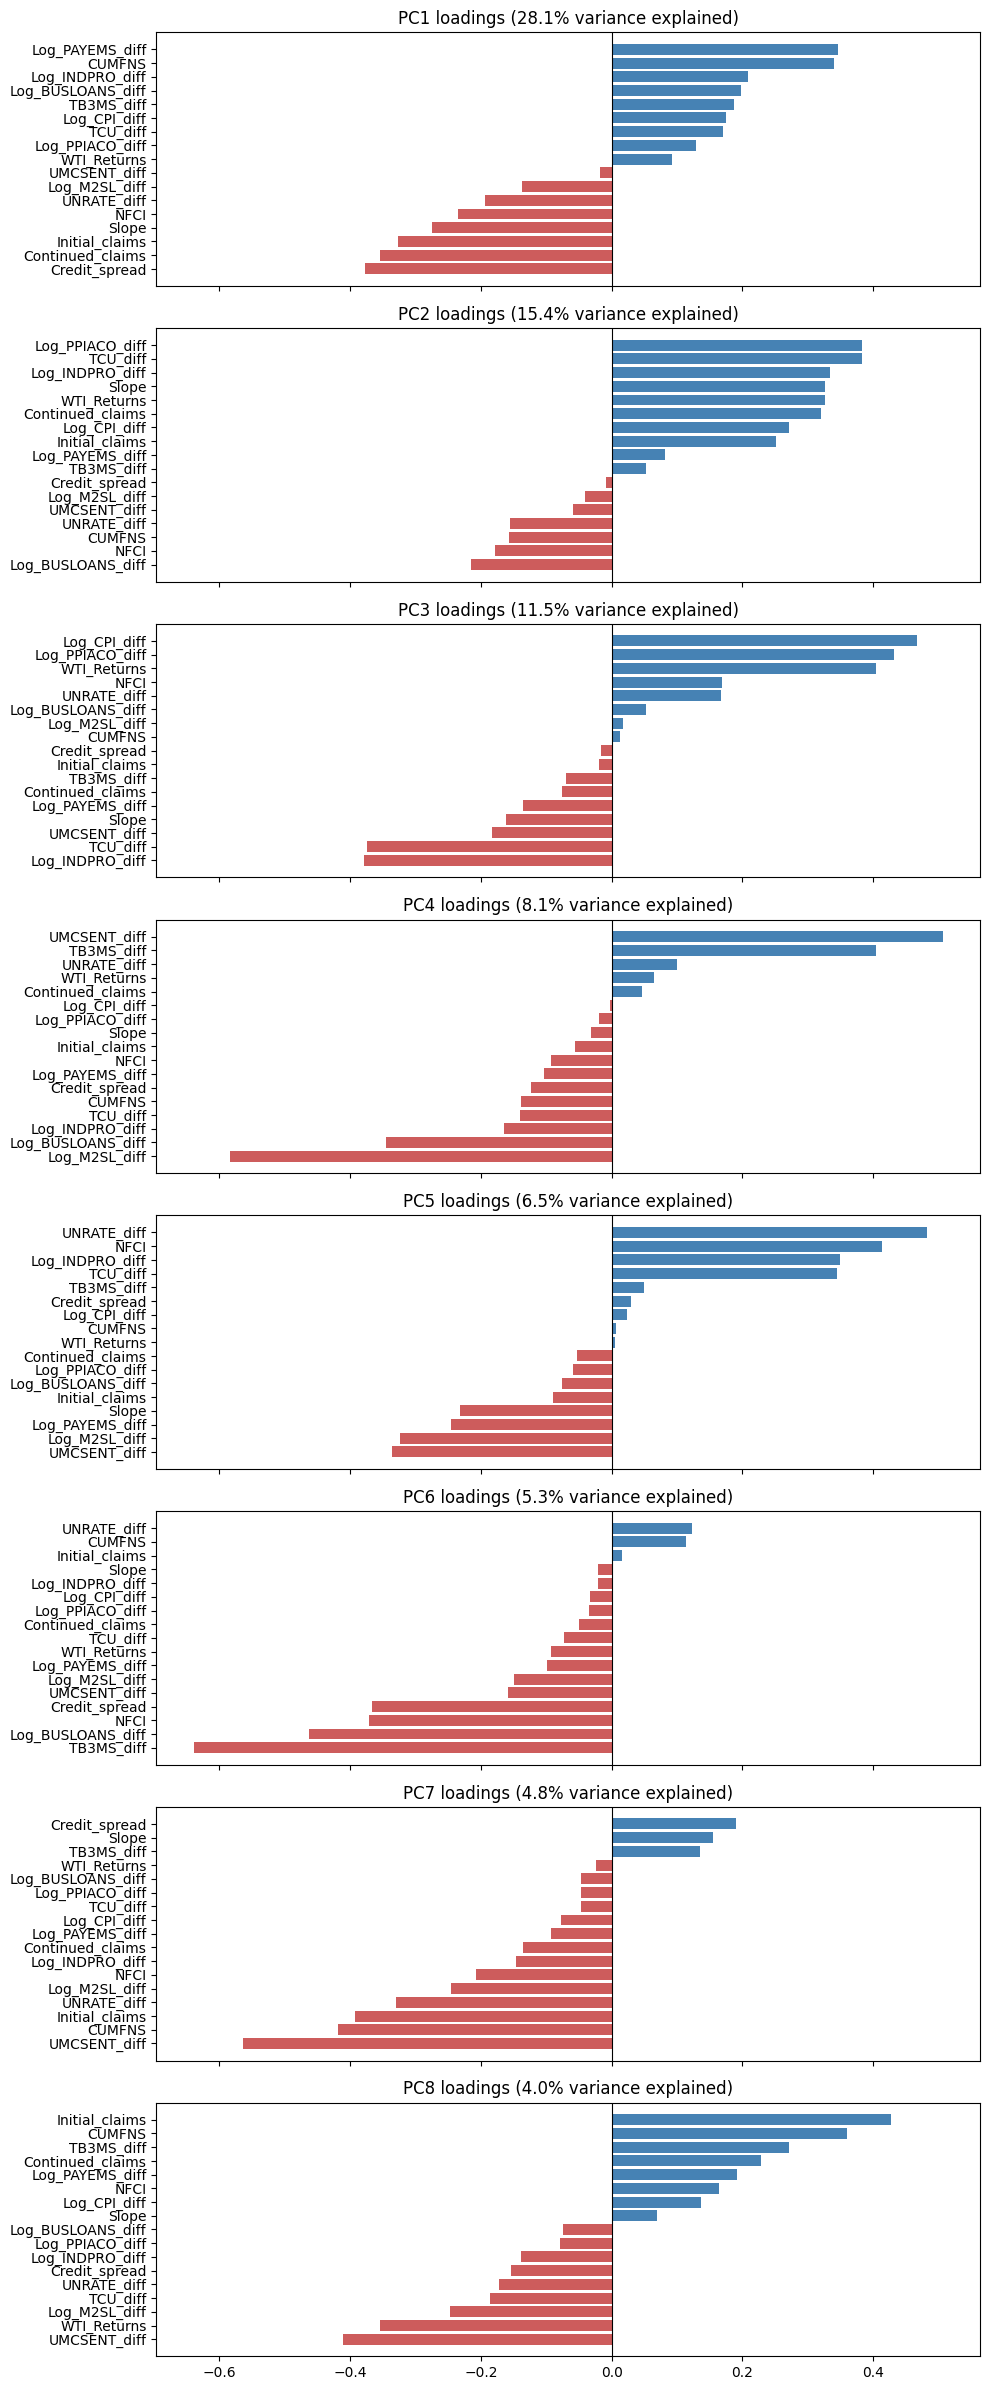

In [20]:
# --- Cell 10: plot loadings for the first 8 components ---

n_components_to_plot = 8

fig, axes = plt.subplots(n_components_to_plot, 1, figsize=(10, 3*n_components_to_plot), sharex=True)

for i in range(n_components_to_plot):
    pc = f'PC{i+1}'
    vals = loadings[pc].sort_values()
    colors = ['steelblue' if v >= 0 else 'indianred' for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors)
    axes[i].set_title(f'{pc} loadings ({explained_var[i]*100:.1f}% variance explained)')
    axes[i].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [21]:
# --- Cell 11: top 5 loadings (by magnitude) for each of the first 8 PCs ---

for i in range(n_components_to_plot):
    pc = f'PC{i+1}'
    top5 = loadings[pc].sort_values(key=abs, ascending=False).head(5)
    print(f"\n--- {pc} top loadings ---")
    print(top5.round(3))


--- PC1 top loadings ---
Credit_spread      -0.377
Continued_claims   -0.355
Log_PAYEMS_diff     0.346
CUMFNS              0.340
Initial_claims     -0.327
Name: PC1, dtype: float64

--- PC2 top loadings ---
Log_PPIACO_diff    0.384
TCU_diff           0.382
Log_INDPRO_diff    0.334
Slope              0.327
WTI_Returns        0.327
Name: PC2, dtype: float64

--- PC3 top loadings ---
Log_CPI_diff       0.467
Log_PPIACO_diff    0.432
WTI_Returns        0.405
Log_INDPRO_diff   -0.379
TCU_diff          -0.374
Name: PC3, dtype: float64

--- PC4 top loadings ---
Log_M2SL_diff       -0.583
UMCSENT_diff         0.506
TB3MS_diff           0.404
Log_BUSLOANS_diff   -0.345
Log_INDPRO_diff     -0.165
Name: PC4, dtype: float64

--- PC5 top loadings ---
UNRATE_diff        0.482
NFCI               0.413
Log_INDPRO_diff    0.349
TCU_diff           0.344
UMCSENT_diff      -0.337
Name: PC5, dtype: float64

--- PC6 top loadings ---
TB3MS_diff          -0.639
Log_BUSLOANS_diff   -0.463
NFCI                

# Finding & Comparison to full PCA

